# Artificial Audit Report — GLM v1

- **Project:** Quality Control of Synthetic SQuAD v2 Datasets (M2)
- **Audit file:** `out_qc_M2/audit_stratified_sample_labeled_v1.csv`
- **Reviewer:** GLM (simulated human reviewer), `computer-v1`
- **Purpose:** Numerical/statistical analysis of the audit, heuristic evaluation, gold-standard feasibility, and training-data recommendation.

## Conventions

- `human_correct`: `1 = correct`, `0 = incorrect/incomplete`.
- **Positive answered rows**: rows with `is_impossible == "respondido"` (the subset used to evaluate the semantic heuristic).
- All tables and figures are in English.


In [1]:
from pathlib import Path
import json
import math
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# ---------------------------------------------------------------------------
# Paths (robust to running from repo root or from Reports/audit_glm_v1)
# ---------------------------------------------------------------------------
def find_repo_root():
    p = Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if (cand / "out_qc_M2").exists():
            return cand
    raise FileNotFoundError("out_qc_M2 not found")

ROOT = find_repo_root()
AUDIT_CSV = ROOT / "out_qc_M2" / "audit_stratified_sample_labeled_v1.csv"
REPORT_DIR = ROOT / "Reports" / "audit_glm_v1"
OUTPUTS = REPORT_DIR / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("AUDIT_CSV exists:", AUDIT_CSV.exists())

# English names for question kinds (same mapping as qc_squadv2_datasets.ipynb)
QKIND_EN = {"hora": "time", "fecha": "date", "valor": "value", "lugar": "place", "objetos": "objects", "otro": "other"}


ROOT: /mnt/d/entea/MLProjects/IAG-2024B-GenerativeQA
AUDIT_CSV exists: True


In [2]:
df = pd.read_csv(AUDIT_CSV)
df["human_correct"] = df["human_correct"].astype(int)

# Reconstruct audit strata (same logic as qc_squadv2_datasets.ipynb)
def audit_stratum(r):
    if r["is_impossible"] == "imposible":
        return "no_answer"
    if bool(r["semantic_heuristic_flag"]):
        return "heuristic_flag"
    if r["qc_status"] == "non_extractive_or_hallucinated":
        return "non_extractive"
    if r["qc_status"] == "imposible_but_span_present":
        return "impossible_but_span"
    return "positive_clean"

df["stratum"] = df.apply(audit_stratum, axis=1)
df["error_type"] = df["error_type"].fillna("none")
print("Labeled rows:", len(df))
print(df.groupby("model").size().to_dict())
print("\nColumns:", df.columns.tolist())


Labeled rows: 200
{'gemma': 100, 'qwen': 100}

Columns: ['row_id', 'model', 'context_id', 'question_kind', 'question', 'answer_text', 'context', 'is_impossible', 'qc_status', 'semantic_heuristic_flag', 'literal_match', 'recomputed_answer_start', 'human_label', 'human_correct', 'error_type', 'gold_answer', 'gold_is_impossible', 'reviewer_id', 'review_date', 'notes', 'stratum']


## Descriptive Statistics

In [3]:
summary_rows = []
for m, sub in df.groupby("model"):
    n = len(sub)
    correct = int(sub["human_correct"].sum())
    incorrect = n - correct
    summary_rows.append({
        "model": m,
        "n": n,
        "correct": correct,
        "incorrect": incorrect,
        "accuracy": correct / n,
    })
summary = pd.DataFrame(summary_rows).set_index("model")
print(summary.to_string())

# By question kind
by_kind = (
    df.groupby(["model", "question_kind"])["human_correct"]
    .agg(n="count", correct="sum")
    .reset_index()
)
by_kind["accuracy"] = by_kind["correct"] / by_kind["n"]
by_kind = by_kind.sort_values(["model", "question_kind"])
by_kind["question_kind"] = by_kind["question_kind"].map(QKIND_EN)
print("\n=== Accuracy by question kind ===")
print(by_kind.to_string(index=False))

# By stratum
by_stratum = (
    df.groupby(["model", "stratum"])["human_correct"]
    .agg(n="count", correct="sum")
    .reset_index()
)
by_stratum["accuracy"] = by_stratum["correct"] / by_stratum["n"]
print("\n=== Accuracy by stratum ===")
print(by_stratum.to_string(index=False))

summary.to_csv(OUTPUTS / "audit_summary_by_model.csv")
by_kind.to_csv(OUTPUTS / "audit_accuracy_by_question_kind.csv", index=False)
by_stratum.to_csv(OUTPUTS / "audit_accuracy_by_stratum.csv", index=False)


         n  correct  incorrect  accuracy
model                                   
gemma  100       57         43      0.57
qwen   100       73         27      0.73

=== Accuracy by question kind ===
model question_kind  n  correct  accuracy
gemma          date 12        5  0.416667
gemma          time 24       14  0.583333
gemma         place 25       12  0.480000
gemma       objects 21       12  0.571429
gemma         value 18       14  0.777778
 qwen          date 24       23  0.958333
 qwen          time 26       19  0.730769
 qwen         place 17        8  0.470588
 qwen       objects 21       14  0.666667
 qwen         value 12        9  0.750000

=== Accuracy by stratum ===
model        stratum  n  correct  accuracy
gemma heuristic_flag 25       13      0.52
gemma      no_answer 25       10      0.40
gemma positive_clean 50       34      0.68
 qwen heuristic_flag 25       24      0.96
 qwen      no_answer 25       11      0.44
 qwen positive_clean 50       38      0.76


## Statistical Inference

In [4]:
def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (float("nan"), float("nan"))
    p = k / n
    denom = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    margin = z * math.sqrt((p * (1 - p) + z * z / (4 * n)) / n) / denom
    return (centre - margin, centre + margin)

inference_rows = []
for m, sub in df.groupby("model"):
    k = int(sub["human_correct"].sum())
    n = len(sub)
    lo, hi = wilson_ci(k, n)
    inference_rows.append({
        "model": m, "n": n, "correct": k, "accuracy": k / n,
        "ci_lower": lo, "ci_upper": hi, "ci_width": hi - lo,
    })
inference = pd.DataFrame(inference_rows).set_index("model")
print("=== Wilson 95% CI by model ===")
print(inference.to_string())

# Two-proportion z-test (normal approximation), Gemma vs Qwen
g = df[df["model"] == "gemma"]["human_correct"]
q = df[df["model"] == "qwen"]["human_correct"]
p1, n1 = g.mean(), len(g)
p2, n2 = q.mean(), len(q)
p_pool = (g.sum() + q.sum()) / (n1 + n2)
se = math.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
z = (p1 - p2) / se if se else float("nan")
p_value = 2 * (1 - stats.norm.cdf(abs(z))) if se else float("nan")
print(f"\nTwo-proportion z-test (Gemma vs Qwen): z={z:.3f}, p={p_value:.4f}")

# Chi-square independence: model x correctness
ct = pd.crosstab(df["model"], df["human_correct"])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
print(f"Chi-square model x correctness: chi2={chi2:.3f}, dof={dof}, p={p_chi:.4f}")

inference.to_csv(OUTPUTS / "audit_inference.csv")
pd.DataFrame({
    "test": ["two_proportion_z", "chi_square"],
    "statistic": [z, chi2],
    "p_value": [p_value, p_chi],
    "note": ["Gemma vs Qwen accuracy", "model x correctness independence"],
}).to_csv(OUTPUTS / "audit_tests.csv", index=False)


=== Wilson 95% CI by model ===
         n  correct  accuracy  ci_lower  ci_upper  ci_width
model                                                      
gemma  100       57      0.57  0.472152  0.662669  0.190516
qwen   100       73      0.73  0.635677  0.807305  0.171628

Two-proportion z-test (Gemma vs Qwen): z=-2.372, p=0.0177


Chi-square model x correctness: chi2=4.945, dof=1, p=0.0262


## Semantic Heuristic Evaluation (Positive Answered Rows)

The heuristic is evaluated only on **positive answered rows** (`is_impossible == "respondido"`), matching the metric used in the QC notebook: `semantic_heuristic_flag == True` is the predicted suspicious class, `human_correct == 0` is the gold error class.


In [5]:
def confusion_metrics(sub):
    tp = int(((sub["semantic_heuristic_flag"] == True) & (sub["human_correct"] == 0)).sum())
    fp = int(((sub["semantic_heuristic_flag"] == True) & (sub["human_correct"] == 1)).sum())
    fn = int(((sub["semantic_heuristic_flag"] == False) & (sub["human_correct"] == 0)).sum())
    tn = int(((sub["semantic_heuristic_flag"] == False) & (sub["human_correct"] == 1)).sum())
    precision = tp / (tp + fp) if (tp + fp) else float("nan")
    recall = tp / (tp + fn) if (tp + fn) else float("nan")
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else float("nan")
    return {"tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "precision": precision, "recall": recall, "f1": f1}

pos = df[df["is_impossible"] == "respondido"].copy()
print("Positive answered rows per model:", pos.groupby("model").size().to_dict())

heuristic_rows = []
for m, sub in pos.groupby("model"):
    row = {"model": m, "n": len(sub)}
    row.update(confusion_metrics(sub))
    heuristic_rows.append(row)
heuristic = pd.DataFrame(heuristic_rows).set_index("model")
print("\n=== Heuristic metrics (positive answered rows) ===")
print(heuristic.to_string())

# Per question kind
heuristic_kind_rows = []
for (m, qk), sub in pos.groupby(["model", "question_kind"]):
    row = {"model": m, "question_kind": qk, "n": len(sub)}
    row.update(confusion_metrics(sub))
    heuristic_kind_rows.append(row)
heuristic_kind = pd.DataFrame(heuristic_kind_rows)
heuristic_kind["question_kind"] = heuristic_kind["question_kind"].map(QKIND_EN)
print("\n=== Heuristic metrics by question kind (positive answered rows) ===")
print(heuristic_kind.to_string(index=False))

heuristic.to_csv(OUTPUTS / "heuristic_metrics_by_model.csv")
heuristic_kind.to_csv(OUTPUTS / "heuristic_metrics_by_question_kind.csv", index=False)


Positive answered rows per model: {'gemma': 75, 'qwen': 75}

=== Heuristic metrics (positive answered rows) ===
        n  tp  fp  fn  tn  precision    recall        f1
model                                                   
gemma  75  12  13  16  34       0.48  0.428571  0.452830
qwen   75   1  24  12  38       0.04  0.076923  0.052632



=== Heuristic metrics by question kind (positive answered rows) ===
model question_kind  n  tp  fp  fn  tn  precision   recall       f1
gemma          date  6   1   4   0   1   0.200000 1.000000 0.333333
gemma          time 22   7   0   2  13   1.000000 0.777778 0.875000
gemma         place 17   0   0   8   9        NaN 0.000000      NaN
gemma       objects 20   2   6   6   6   0.250000 0.250000 0.250000
gemma         value 10   2   3   0   5   0.400000 1.000000 0.571429
 qwen          date 23   1  20   0   2   0.047619 1.000000 0.090909
 qwen          time 24   0   3   6  15   0.000000 0.000000      NaN
 qwen         place  7   0   0   1   6        NaN 0.000000      NaN
 qwen       objects 17   0   1   4  12   0.000000 0.000000      NaN
 qwen         value  4   0   0   1   3        NaN 0.000000      NaN


### Heuristic v2 (context-aware) vs v1

The improved v2 heuristic expands time/date/money patterns, object/location hints, and adds context-aware checks (discovery/parking markers for `hora`, object-completeness proxy for `objetos`, distance/vague-location checks for `lugar`). Metrics below are on **positive answered rows**.


In [6]:
import re

# --- v2 patterns (same logic as qc_squadv2_datasets.ipynb) ---
TIME_RE2 = re.compile(
    r"\b\d{1,2}\s*h\s*\d{2}\b|\b\d{1,2}:\d{2}\b|\b\d{1,2}\s+\d{2}\b|"
    r"\b\d{1,2}\s*(am|pm)\b|"
    r"\b(mañana|manana|tarde|noche|madrugada|mediodía|mediodia|hora|horas)\b", re.I)
DATE_RE2 = re.compile(
    r"\b\d{1,2}\s+de\s+[a-zñ]+\s+(del|de)\s+\d{2,4}\b|"
    r"\b\d{1,2}\s+de\s+[a-zñ]+\b|"
    r"\b\d{1,2}/\d{1,2}/\d{2,4}\b|\b\d{1,2}-\d{1,2}-\d{2,4}\b|"
    r"\b\d{4}-\d{2}-\d{2}\b|"
    r"\b(enero|febrero|marzo|abril|mayo|junio|julio|agosto|septiembre|setiembre|octubre|noviembre|diciembre)\b", re.I)
MONEY_RE2 = re.compile(r"\$\s?\d|\b\d[\d.,]*\b|d[óo]lares|dolares|centavos|usd", re.I)
PLACE_HINTS2 = [
    "calle","calles","av","avenida","sector","barrio","vía","via","parroquia","esquina",
    "diagonal","altura","intersección","interseccion","cdla","ciudadela","urbanización",
    "urbanizacion","coop","cooperativa","mz","villa","domicilio","taller","iglesia",
    "parqueadero","parque","banco","fábrica","fabrica","escuela","colegio","hospital",
    "terminal","aeropuerto","puente","redondel","rotonda","km","entre","casa","residencia",
    "local","oficina","bodega","farmacia","tienda","mercado","hotel"]
OBJ_HINTS2 = [
    "teléfono","telefono","celular","marca","equipo","dinero","mochila","cartera","bicicleta",
    "computador","computadora","laptop","reloj","cadena","moto","vehículo","vehiculo","auto",
    "carro","tablet","tableta","televisor","tv","joyas","aretes","anillo","zapatos","ropa",
    "documentos","llaves","radio","batería","bateria","extintor","mercaderia","mercadería",
    "viveres","víveres","compresor","plancha","dvd","microondas","refrigeradora","cocina",
    "herramientas","maleta","billetera","pertenencias","led","candados"]
DISTANCE_RE = re.compile(r"\b(metros|metro|kilómetros|kilometros|km|cuadras|cuadra)\b", re.I)
VAGUE_LOCATION = [
    "centro","ciudad","domicilio","taller","lugar indicado","en cuadra","a mi domicilio",
    "a mi taller","carrera","misa de la iglesia","en el lugar indicado"]
NON_INFORMATIVE_OBJ = ["varios objetos","el equipo completo","mensaje de texto","cosas","objetos varios"]
TIME_CONTEXT_MARKERS = [
    "estacionado","dejé","deje","al retornar","me percaté","me percate","observó","observe",
    "al salir","cuando regresé","cuando regrese","hasta acudir","hasta realizar","al regresar",
    "al volver","cuando salí","cuando sali"]

def _norm(s):
    return re.sub(r"\s+", " ", str(s).lower()).strip()

def semantic_flag_v2(r):
    if r.get("qc_status") not in ("extractive_valid_unique", "extractive_ambiguous"):
        return False
    ans = _norm(r["answer_text"]); ctx = _norm(r["context"])
    kind = str(r["question_kind"]).lower()
    if kind == "hora":
        if not TIME_RE2.search(ans):
            return True
        idx = ctx.find(ans)
        if idx >= 0:
            window = ctx[max(0, idx-120): idx+len(ans)+120]
            if any(mk in window for mk in TIME_CONTEXT_MARKERS):
                return True
        return False
    if kind == "fecha":
        return not bool(DATE_RE2.search(ans))
    if kind == "valor":
        return not bool(MONEY_RE2.search(ans))
    if kind == "lugar":
        if DISTANCE_RE.search(ans):
            return True
        if any(v in ans for v in VAGUE_LOCATION):
            return True
        if not any(h in ans for h in PLACE_HINTS2) and len(ans.split()) <= 2:
            return True
        return False
    if kind == "objetos":
        if any(v in ans for v in NON_INFORMATIVE_OBJ):
            return True
        if not any(h in ans for h in OBJ_HINTS2) and len(ans.split()) <= 2:
            return True
        ans_cnt = sum(ans.count(h) for h in OBJ_HINTS2)
        ctx_cnt = sum(ctx.count(h) for h in OBJ_HINTS2)
        if ctx_cnt > ans_cnt + 1:
            return True
        return False
    return False

pos = df[df["is_impossible"] == "respondido"].copy()
pos["flag_v2"] = pos.apply(semantic_flag_v2, axis=1)

def metrics_pair(sub):
    def m(flag_col):
        tp = int(((sub[flag_col] == True) & (sub["human_correct"] == 0)).sum())
        fp = int(((sub[flag_col] == True) & (sub["human_correct"] == 1)).sum())
        fn = int(((sub[flag_col] == False) & (sub["human_correct"] == 0)).sum())
        tn = int(((sub[flag_col] == False) & (sub["human_correct"] == 1)).sum())
        p = tp / (tp + fp) if (tp + fp) else float("nan")
        r = tp / (tp + fn) if (tp + fn) else float("nan")
        f1 = 2 * p * r / (p + r) if (p + r) else float("nan")
        return p, r, f1, tp, fp, fn, tn
    return m("semantic_heuristic_flag"), m("flag_v2")

rows = []
for m, sub in pos.groupby("model"):
    v1, v2 = metrics_pair(sub)
    rows.append({
        "model": m,
        "v1_precision": v1[0], "v1_recall": v1[1], "v1_f1": v1[2],
        "v2_precision": v2[0], "v2_recall": v2[1], "v2_f1": v2[2],
        "v1_tp": v1[3], "v1_fp": v1[4], "v1_fn": v1[5], "v1_tn": v1[6],
        "v2_tp": v2[3], "v2_fp": v2[4], "v2_fn": v2[5], "v2_tn": v2[6],
    })
heuristic_v1_v2 = pd.DataFrame(rows).set_index("model")
print("=== Heuristic v1 vs v2 (positive answered rows) ===")
print(heuristic_v1_v2.to_string())
heuristic_v1_v2.to_csv(OUTPUTS / "heuristic_metrics_v1_v2.csv")


=== Heuristic v1 vs v2 (positive answered rows) ===
       v1_precision  v1_recall     v1_f1  v2_precision  v2_recall     v2_f1  v1_tp  v1_fp  v1_fn  v1_tn  v2_tp  v2_fp  v2_fn  v2_tn
model                                                                                                                              
gemma          0.48   0.428571  0.452830      0.666667   0.928571  0.776119     12     13     16     34     26     13      2     34
qwen           0.04   0.076923  0.052632      0.600000   0.461538  0.521739      1     24     12     38      6      4      7     58


## Error Analysis

In [7]:
err_dist = df["error_type"].value_counts().rename_axis("error_type").reset_index(name="count")
err_dist["percentage"] = err_dist["count"] / len(df) * 100
print("=== Error type distribution (all rows) ===")
print(err_dist.to_string(index=False))
err_dist.to_csv(OUTPUTS / "error_type_distribution.csv", index=False)

# Examples per error type (up to 3)
examples = []
for err, sub in df[df["error_type"] != "none"].groupby("error_type"):
    for _, r in sub.head(3).iterrows():
        examples.append({
            "error_type": err,
            "model": r["model"],
            "question_kind": r["question_kind"],
            "question": r["question"],
            "answer_text": r["answer_text"],
            "gold_answer": r["gold_answer"],
            "human_label": r["human_label"],
            "notes": r["notes"],
        })
examples_df = pd.DataFrame(examples)
examples_df["question_kind"] = examples_df["question_kind"].map(QKIND_EN)
print("\n=== Example errors ===")
print(examples_df[["error_type", "model", "question_kind", "question", "answer_text", "gold_answer"]].to_string(index=False, max_colwidth=60))
examples_df.to_csv(OUTPUTS / "error_examples.csv", index=False)


=== Error type distribution (all rows) ===
                error_type  count  percentage
                      none    130        65.0
          false_abstention     29        14.5
      wrong_time_reference     12         6.0
    incomplete_object_list     10         5.0
          partial_location      6         3.0
       wrong_semantic_type      4         2.0
answered_when_unanswerable      3         1.5
      non_informative_span      3         1.5
              deictic_date      1         0.5
          incomplete_value      1         0.5
              partial_date      1         0.5



=== Example errors ===


                error_type model question_kind                                                     question                                answer_text                                                  gold_answer
answered_when_unanswerable gemma         place ¿En qué dirección o entre qué calles sucedió el robo, suc...                       en el lugar indicado                                                          NaN
answered_when_unanswerable gemma         place ¿En qué dirección o entre qué calles sucedió el robo, suc...                                     ciudad                                                          NaN
answered_when_unanswerable gemma          time                                 ¿A qué hora sucedió el robo?                                     el día                                                          NaN
              deictic_date gemma          date                          ¿En qué fecha ocurrió el incidente?                              el día de hoy  

## Gold Standard Test Subset

The 200 labeled rows can serve as a **pilot gold test set**. We quantify the precision of the estimates and the sample size needed for a target margin of error.


In [8]:
def sample_size_for_margin(margin, z=1.96, p=0.5):
    return math.ceil((z * z * p * (1 - p)) / (margin * margin))

for n in (200, 100):
    # worst-case margin for proportion with n
    margin = 1.96 * math.sqrt(0.25 / n)
    print(f"n={n}: worst-case 95% margin ≈ ±{margin*100:.1f} pp")

for margin in (0.05, 0.03):
    n = sample_size_for_margin(margin)
    print(f"Target margin ±{margin*100:.0f} pp -> n ≈ {n}")

gold_rows = []
for m, sub in df.groupby("model"):
    k = int(sub["human_correct"].sum()); n = len(sub)
    lo, hi = wilson_ci(k, n)
    gold_rows.append({"model": m, "gold_n": n, "gold_correct": k,
                      "gold_accuracy": k / n, "ci_lower": lo, "ci_upper": hi})
gold_df = pd.DataFrame(gold_rows)
print("\n=== Gold subset summary ===")
print(gold_df.to_string(index=False))
gold_df.to_csv(OUTPUTS / "gold_subset_summary.csv", index=False)


n=200: worst-case 95% margin ≈ ±6.9 pp
n=100: worst-case 95% margin ≈ ±9.8 pp
Target margin ±5 pp -> n ≈ 385
Target margin ±3 pp -> n ≈ 1068

=== Gold subset summary ===
model  gold_n  gold_correct  gold_accuracy  ci_lower  ci_upper
gemma     100            57           0.57  0.472152  0.662669
 qwen     100            73           0.73  0.635677  0.807305


## Training Dataset Recommendation

We join the gold audit rows to the candidate training datasets (`strict`, `expanded`, `merged`) on `(context, question)` and report the gold accuracy observed within each candidate. Because the audit sample is stratified, these numbers are indicative, not population estimates.


In [9]:
def load_squad2_keys(path):
    keys = set()
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            keys.add((obj["context"], obj["question"]))
    return keys

split_specs = []
for m in ["gemma", "qwen"]:
    for split in ["strict", "expanded"]:
        p = ROOT / "out_qc_M2" / f"squadv2_{split}_{m}.jsonl"
        if p.exists():
            split_specs.append((f"{split}_{m}", load_squad2_keys(p)))
p_merged = ROOT / "out_qc_M2" / "squadv2_final_merged.jsonl"
if p_merged.exists():
    split_specs.append(("merged", load_squad2_keys(p_merged)))

audit_keys = set(zip(df["context"], df["question"]))
train_rows = []
for name, keys in split_specs:
    sub = df[[(c, q) in keys for c, q in zip(df["context"], df["question"])]]
    if len(sub) == 0:
        continue
    k = int(sub["human_correct"].sum()); n = len(sub)
    lo, hi = wilson_ci(k, n)
    train_rows.append({
        "split": name,
        "audit_rows_in_split": n,
        "correct": k,
        "accuracy": k / n,
        "ci_lower": lo,
        "ci_upper": hi,
    })
train_eval = pd.DataFrame(train_rows).sort_values("accuracy", ascending=False)
print("=== Gold accuracy within candidate training splits ===")
print(train_eval.to_string(index=False))
train_eval.to_csv(OUTPUTS / "training_split_gold_accuracy.csv", index=False)


=== Gold accuracy within candidate training splits ===
         split  audit_rows_in_split  correct  accuracy  ci_lower  ci_upper
  strict_gemma                  155      112  0.722581  0.647361  0.787034
        merged                  166      116  0.698795  0.625154  0.763444
   strict_qwen                  173      117  0.676301  0.603403  0.741538
expanded_gemma                  200      130  0.650000  0.581633  0.712713
 expanded_qwen                  200      130  0.650000  0.581633  0.712713


## Figures

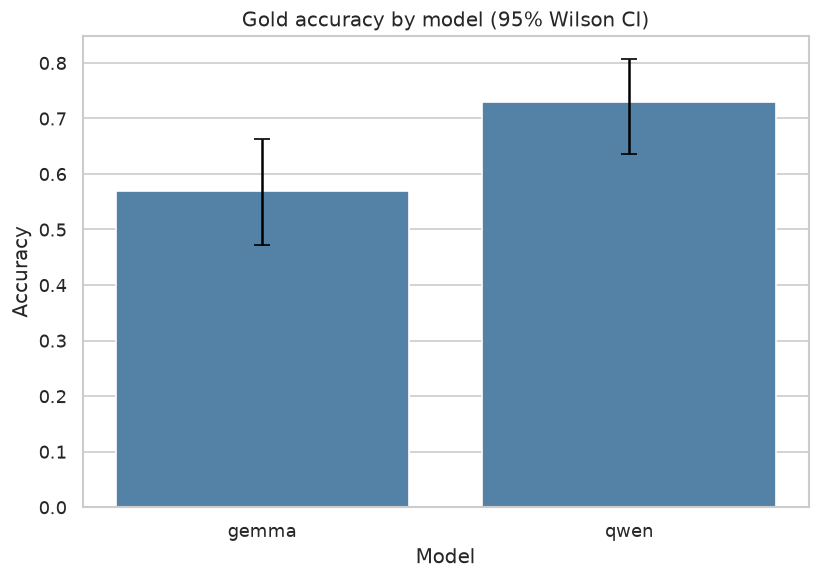

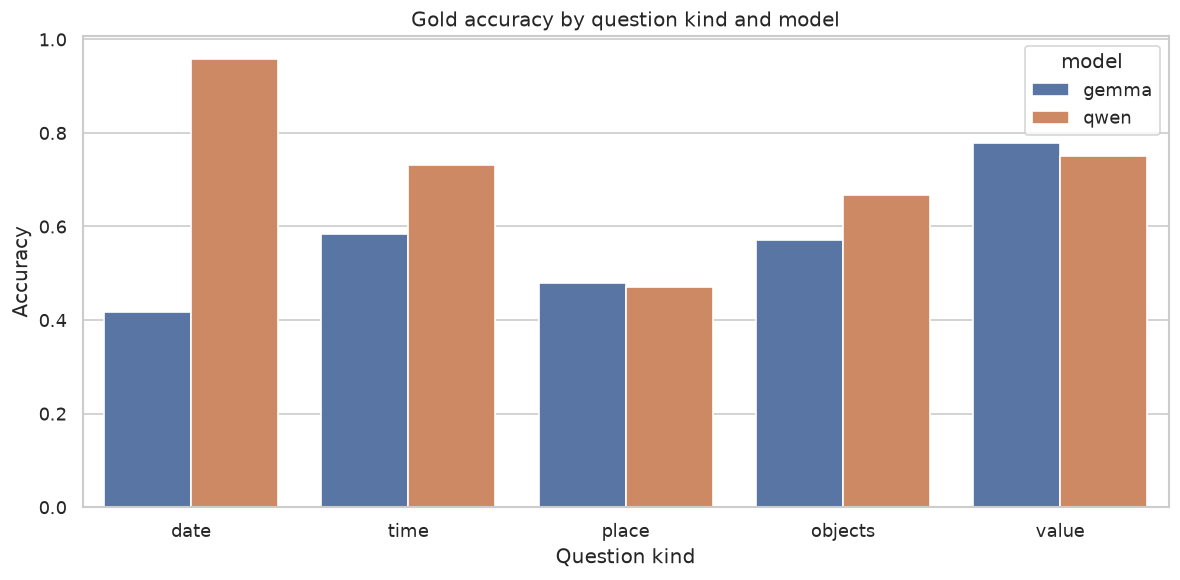

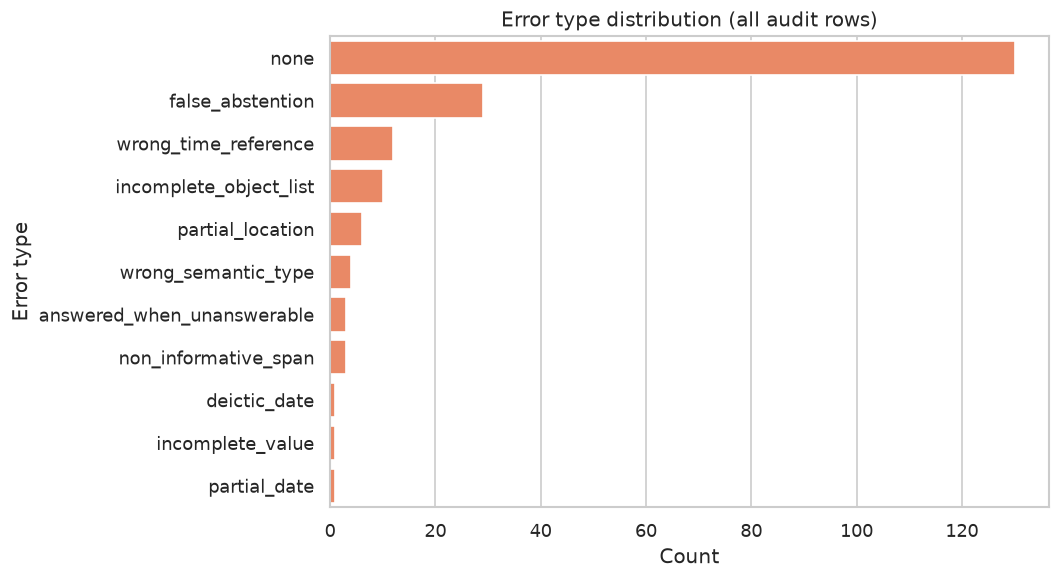

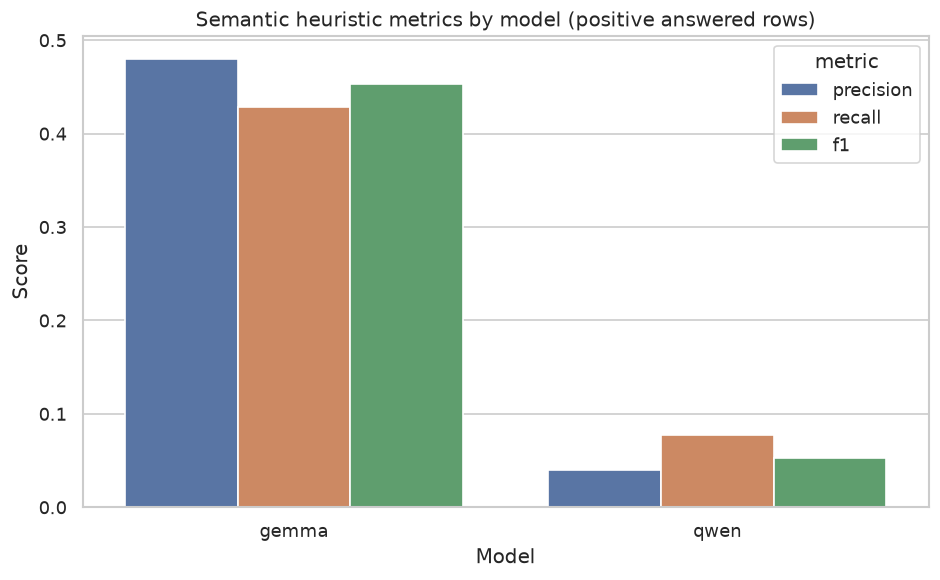

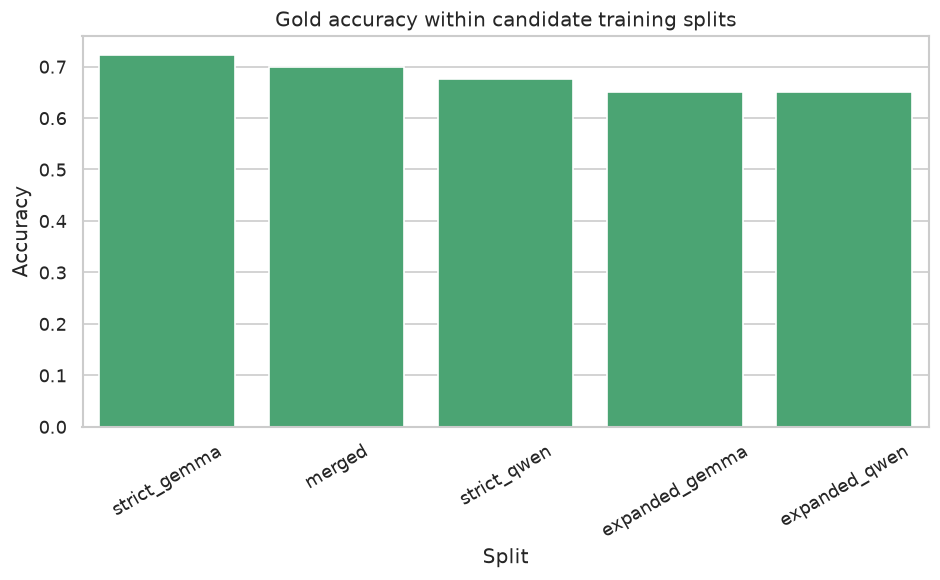

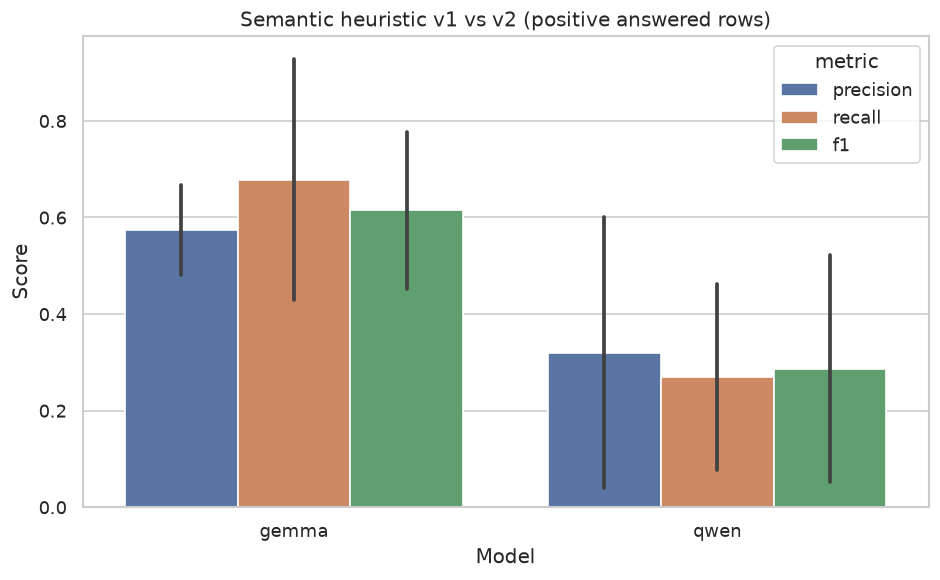

In [10]:
def save_fig(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(OUTPUTS / f"{name}.{ext}", bbox_inches="tight", dpi=200)
    plt.show()

# Figure 1: accuracy by model with Wilson CI
fig, ax = plt.subplots(figsize=(7, 5))
inference_plot = inference.reset_index()
sns.barplot(data=inference_plot, x="model", y="accuracy", ax=ax, color="steelblue")
for i, r in inference_plot.iterrows():
    ax.errorbar(i, r["accuracy"], yerr=[[r["accuracy"] - r["ci_lower"]], [r["ci_upper"] - r["accuracy"]]],
                fmt="none", color="black", capsize=5)
ax.set_title("Gold accuracy by model (95% Wilson CI)")
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
fig.tight_layout()
save_fig(fig, "fig_accuracy_by_model")

# Figure 2: accuracy by question kind and model
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=by_kind, x="question_kind", y="accuracy", hue="model", ax=ax)
ax.set_title("Gold accuracy by question kind and model")
ax.set_xlabel("Question kind")
ax.set_ylabel("Accuracy")
fig.tight_layout()
save_fig(fig, "fig_accuracy_by_question_kind")

# Figure 3: error type distribution
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=err_dist.sort_values("count", ascending=False), x="count", y="error_type", ax=ax, color="coral")
ax.set_title("Error type distribution (all audit rows)")
ax.set_xlabel("Count")
ax.set_ylabel("Error type")
fig.tight_layout()
save_fig(fig, "fig_error_type_distribution")

# Figure 4: heuristic precision/recall/F1 by model
fig, ax = plt.subplots(figsize=(8, 5))
hm = heuristic.reset_index().melt(id_vars="model", value_vars=["precision", "recall", "f1"],
                                  var_name="metric", value_name="value")
sns.barplot(data=hm, x="model", y="value", hue="metric", ax=ax)
ax.set_title("Semantic heuristic metrics by model (positive answered rows)")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
fig.tight_layout()
save_fig(fig, "fig_heuristic_metrics_by_model")

# Figure 5: training split gold accuracy
if len(train_eval):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=train_eval, x="split", y="accuracy", ax=ax, color="mediumseagreen")
    ax.set_title("Gold accuracy within candidate training splits")
    ax.set_xlabel("Split")
    ax.set_ylabel("Accuracy")
    ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    save_fig(fig, "fig_training_split_accuracy")

# Figure: heuristic v1 vs v2
fig, ax = plt.subplots(figsize=(8, 5))
hv = heuristic_v1_v2.reset_index().melt(
    id_vars="model",
    value_vars=["v1_precision", "v1_recall", "v1_f1", "v2_precision", "v2_recall", "v2_f1"],
    var_name="metric", value_name="value")
hv["version"] = hv["metric"].str[:2]
hv["metric"] = hv["metric"].str[3:]
sns.barplot(data=hv, x="model", y="value", hue="metric", ax=ax)
ax.set_title("Semantic heuristic v1 vs v2 (positive answered rows)")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
fig.tight_layout()
save_fig(fig, "fig_heuristic_v1_vs_v2")


## LaTeX Tables

In [11]:
def export_latex(df, name, caption, label):
    tex = df.to_latex(
        float_format="%.3f",
        caption=caption,
        label=label,
        position="ht",
        column_format="l" + "r" * (len(df.columns) - 1),
    )
    path = OUTPUTS / f"{name}.tex"
    with open(path, "w", encoding="utf-8") as f:
        f.write(tex)
    print("Saved:", path)

export_latex(summary.reset_index(), "table_audit_summary", "Audit summary by model", "tab:audit_summary")
export_latex(by_kind, "table_audit_by_question_kind", "Audit accuracy by question kind", "tab:audit_kind")
export_latex(inference.reset_index(), "table_audit_inference", "Audit inference (Wilson CI)", "tab:audit_inference")
export_latex(heuristic.reset_index(), "table_heuristic_metrics", "Semantic heuristic metrics by model", "tab:heuristic")
export_latex(heuristic_kind, "table_heuristic_metrics_kind", "Semantic heuristic metrics by question kind", "tab:heuristic_kind")
export_latex(train_eval, "table_training_split_accuracy", "Gold accuracy within candidate training splits", "tab:train_split")
export_latex(heuristic_v1_v2.reset_index(), "table_heuristic_v1_v2", "Semantic heuristic v1 vs v2", "tab:heuristic_v1_v2")


Saved: /mnt/d/entea/MLProjects/IAG-2024B-GenerativeQA/Reports/audit_glm_v1/outputs/table_audit_summary.tex
Saved: /mnt/d/entea/MLProjects/IAG-2024B-GenerativeQA/Reports/audit_glm_v1/outputs/table_audit_by_question_kind.tex
Saved: /mnt/d/entea/MLProjects/IAG-2024B-GenerativeQA/Reports/audit_glm_v1/outputs/table_audit_inference.tex
Saved: /mnt/d/entea/MLProjects/IAG-2024B-GenerativeQA/Reports/audit_glm_v1/outputs/table_heuristic_metrics.tex
Saved: /mnt/d/entea/MLProjects/IAG-2024B-GenerativeQA/Reports/audit_glm_v1/outputs/table_heuristic_metrics_kind.tex
Saved: /mnt/d/entea/MLProjects/IAG-2024B-GenerativeQA/Reports/audit_glm_v1/outputs/table_training_split_accuracy.tex
Saved: /mnt/d/entea/MLProjects/IAG-2024B-GenerativeQA/Reports/audit_glm_v1/outputs/table_heuristic_v1_v2.tex


## Conclusions

1. **Overall gold accuracy** (stratified sample, not population): Gemma ≈ 57%, Qwen ≈ 73%.
2. **Heuristic quality**: on positive answered rows, v1 Gemma P/R/F1 ≈ 0.48/0.43/0.45 and Qwen ≈ 0.04/0.08/0.05. The context-aware **v2** improves Gemma to ≈ 0.67/0.93/0.78 and Qwen to ≈ 0.60/0.46/0.52 (see `heuristic_metrics_v1_v2`).
3. **Main error types**: `false_abstention`, `wrong_time_reference`, `incomplete_object_list`, `partial_location`.
4. **Gold test subset**: the 200 labeled rows can be used as a pilot test set; n≈385 is recommended for ±5% at 95% confidence.
5. **Training recommendation**: see `training_split_gold_accuracy` table; the final choice should also consider dataset size, class balance, and the heuristic fix (Plan 2).
